In [1]:
import os
os.getcwd()

'/home/nic/aether/imaging-notes'

In [2]:
import silmaril
import astropy
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

s = astropy.coordinates.SkyCoord(24.3468342,-8.4645026,unit="deg")
image_plane = silmaril.Grid(s,1000,0.031) # 0.031 arcseconds per pixel, 1000 pixels
wcs = astropy.wcs.WCS(astropy.io.fits.open(r"/mnt/sim/hlsp_relics_model_whl0137-08_glafic_v1_x-arcsec-deflect.fits")[0].header)
x_deflections = silmaril.open_fits(r"/mnt/sim/hlsp_relics_model_whl0137-08_glafic_v1_x-arcsec-deflect.fits")
y_deflections = silmaril.open_fits(r"/mnt/sim/hlsp_relics_model_whl0137-08_glafic_v1_y-arcsec-deflect.fits")

# fits file is the standard for astronomy community for 

# hdul = fits.open(r"C:\\Users\\josep\Documents\\Python Projects\\hlsp_relics_model_whl0137-08_glafic_v1_x-arcsec-deflect.fits")
# hdul.info()

lens = silmaril.Lens(x_deflections,y_deflections,wcs,redshift=0.566,unit='arcsec')

#Line below is characterized by the "detector"
detector = silmaril.Detector(resolution=0.031,fov=30,center=astropy.coordinates.SkyCoord(24.34819561, -8.46520946,unit="deg"),psf_fwhm=2.065)

conv = lens.convergence(image_plane,6.2)
mag_line = lens.magnification_line(image_plane,6.2)

In [3]:
import yt 
epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

ds = yt.load('/mnt/sim/output_00273/info_00273.txt', extra_particle_fields=epf)
ad = ds.all_data() 

yt : [WARNING  ] 2026-03-23 18:00:06,052 `namelist.txt` file found but missing package f90nml to read it:
Traceback (most recent call last):
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/frontends/ramses/data_structures.py", line 1139, in read_namelist
    nml = f90nml.read(f)
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/utilities/on_demand_imports.py", line 39, in __call__
    raise self.error
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/utilities/on_demand_imports.py", line 77, in inner
    return func(self)
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/utilities/on_demand_imports.py", line 420, in read
    from f90nml import read
ModuleNotFoundError: No module named 'f90nml'
Something went wrong while trying to lazy-import f90nml. Please make sure that f90nml is properly installed.
If the problem persists, please file an issue at https://github.com/yt-project/yt/

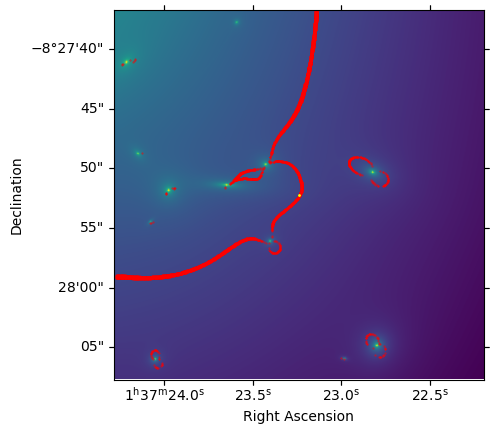

In [4]:
ax = plt.subplot(projection=image_plane.wcs)
ax.imshow(np.log10(abs(conv)),origin="lower")
 # Color shows distribution of mass in the lens plane; start with angles and derive mass per unit area
ax.scatter(mag_line[:,0],mag_line[:,1],s=0.1,color="red",transform=ax.get_transform('world')) #Red line = caustics
ax.scatter(24.3468342,-8.4645026,s=1,color="yellow",transform=ax.get_transform('world')) # Yellow dot on red line is where the image is!
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')


In [5]:
lens.trace_points([[24.3468342,-8.4645026]],6.2)

array([24.35380691, -8.45843597])

yt : [WARNING  ] 2026-03-23 18:01:05,464 `namelist.txt` file found but missing package f90nml to read it:
Traceback (most recent call last):
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/frontends/ramses/data_structures.py", line 1139, in read_namelist
    nml = f90nml.read(f)
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/utilities/on_demand_imports.py", line 39, in __call__
    raise self.error
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/utilities/on_demand_imports.py", line 77, in inner
    return func(self)
  File "/home/nic/miniconda3/envs/pyart_env/lib/python3.14/site-packages/yt/utilities/on_demand_imports.py", line 420, in read
    from f90nml import read
ModuleNotFoundError: No module named 'f90nml'
Something went wrong while trying to lazy-import f90nml. Please make sure that f90nml is properly installed.
If the problem persists, please file an issue at https://github.com/yt-project/yt/

Filename = /mnt/sim/output_00273/info_00273.txt
File Directory = /mnt/sim/output_00273
Output File = output_00273
Simulation Run = 00273
Analysis Directory = analysis/output_00273_analysis


yt : [INFO     ] 2026-03-23 18:01:13,563 Identified 1 intersecting domains
yt : [INFO     ] 2026-03-23 18:01:24,352 Projection completed
yt : [INFO     ] 2026-03-23 18:01:24,354 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:01:24,354 ylim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:01:24,358 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:01:24,360 ylim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:01:24,364 Making a fixed resolution buffer of (('deposit', 'star_sum_lum_F200W')) 1000 by 1000


(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

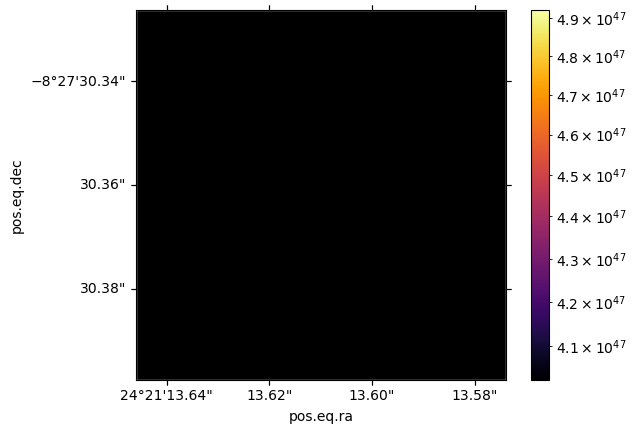

In [ ]:
# Line below gives the position of the galaxy--play with this!
galaxy = silmaril.Galaxy("output_00273.txt",redshift=6.2,size=200,center=astropy.coordinates.SkyCoord(24.35378054, -8.45843384,unit="deg"),extra="/mnt/sim/output_00273/info_00273.txt"); # loads in the actual galaxy at the source plane
observation = silmaril.Observation(detector,lens,galaxy);

galaxy.plot(1000, custom = True)

# Image of the galaxy is shown below! (source plane) color = luminosity

In [ ]:
galaxy.pixel_scale(resolution=1000,zoom_factor=1)

lensed_image = observation.simulate_observation(background=3e-11,noise=5e-12,source_resolution=1000,star_by_star=True, filter_name="F200W")
observation.plot(background=0,noise=0,source_resolution=1000,star_by_star=False,custom=True, filter_name="F277W")

# Actual lensed image simulation

yt : [INFO     ] 2026-03-23 18:04:47,155 Identified   162/  384 intersecting domains (  385 through hilbert key indexing)
yt : [INFO     ] 2026-03-23 18:04:47,250 Identified 1 intersecting domains
yt : [INFO     ] 2026-03-23 18:04:55,310 Projection completed
yt : [INFO     ] 2026-03-23 18:04:55,320 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,321 ylim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,326 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,327 ylim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,328 Making a fixed resolution buffer of (('deposit', 'star_sum_lum_F277W')) 1000 by 1000


(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

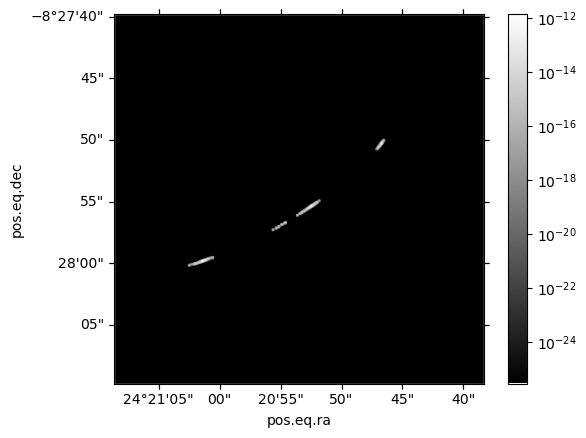

In [ ]:
observation.plot(background=0,noise=0,source_resolution=1000,star_by_star=True,filter_name="F277W")

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

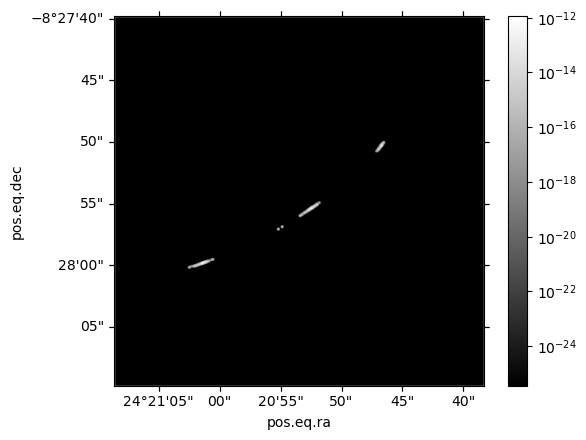

In [12]:
observation.plot(background=0,noise=0,source_resolution=1000,filter_name="F070W")

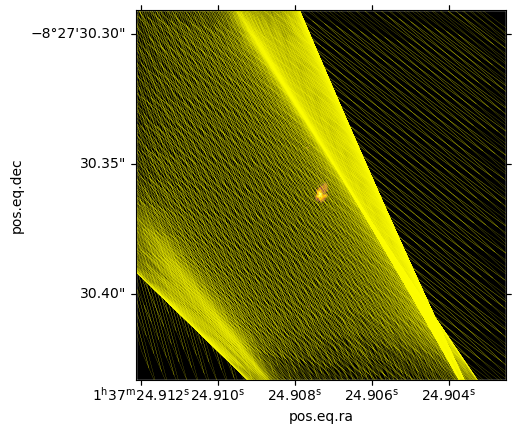

In [10]:

from matplotlib.patches import Polygon
import matplotlib as mpl
from matplotlib.colors import LogNorm
nonempty_pixels, arc_pixels, polygons, luminosities = observation.trace_pixels(source_resolution=1000,zoom_factor=2)

ax = plt.subplot(projection=galaxy.grid(1000,2).wcs)
ax.imshow(galaxy.create_image(resolution=1000,zoom_factor=2),norm=LogNorm(1e-9,1e-7),cmap="inferno")
polygons = [Polygon(p,closed=True,fill=False,color="yellow",lw=0.1,transform=ax.get_transform('world')) for p in polygons]

ax.set_facecolor('black')
for i,p in enumerate(polygons):
    ax.add_patch(p)

    #Image shows grid overlayed on the galaxy (lines are actually elongated grids)